# Polynomial Regression - From Math to Plot

This notebook demonstrates **Polynomial Regression** on a tiny, hand-picked dataset (6 points). It walks through:

1. The **mathematical formulas** (LaTeX)
2. **Step-by-step training** using the Normal Equation
3. A **tabular** view of the design matrix, predictions and residuals
4. A **detailed set of plots** (true curve, fitted curve, residuals, coefficient bars)

> Style inspired by `polynomial-regrassion.ipynb` (linear regression via the explanatory design-matrix approach).


## 1. Import Libraries

We use `numpy` for the matrix math, `pandas` for the tables, and `matplotlib`/`seaborn` for the figures.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
np.set_printoptions(suppress=True, precision=4)


## 2. The Small Dataset

We craft 6 points that follow a clean **quadratic** relationship so the math stays readable:

$$y = 1 + 2x + 0.5x^{2}$$

| x | y |
|---|---|
| 1 | 3.5 |
| 2 | 7.0 |
| 3 | 11.5 |
| 4 | 17.0 |
| 5 | 23.5 |
| 6 | 31.0 |

Because the data is exactly quadratic, a **degree-2** polynomial will fit it perfectly (R2 = 1.0), which makes every intermediate value easy to verify by hand.


In [11]:
# Raw 1-D input
x = np.array([1, 2, 3, 4, 5, 6], dtype=float)

# Target generated from y = 1 + 2x + 0.5 x^2
y = 1 + 2*x + 0.5*x**2

df = pd.DataFrame({'x': x, 'y': y})
print('=== SMALL INPUT SOURCE DATA ===')
print(df.to_string(index=False))
print('=' * 40)


=== SMALL INPUT SOURCE DATA ===
  x    y
1.0  3.5
2.0  7.0
3.0 11.5
4.0 17.0
5.0 23.5
6.0 31.0


## 3. The Mathematics of Polynomial Regression

A degree-`d` polynomial hypothesis is:

$$h_{\beta}(x) = \beta_0 + \beta_1 x + \beta_2 x^{2} + \dots + \beta_d x^{d} = \sum_{j=0}^{d} \beta_j x^{j}$$

We stack every feature power into a **design matrix** $\mathbf{X}$ (with a leading column of 1s for the intercept):

$$\mathbf{X} = \begin{bmatrix} 1 & x_1 & x_1^{2} & \dots & x_1^{d} \\ 1 & x_2 & x_2^{2} & \dots & x_2^{d} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_n & x_n^{2} & \dots & x_n^{d} \end{bmatrix}$$

We minimise the ordinary least-squares cost:

$$J(\beta) = \frac{1}{2n}\sum_{i=1}^{n}\left(h_{\beta}(x_i) - y_i\right)^{2}$$

Setting the gradient to zero yields the closed-form **Normal Equation**:

$$\hat{\beta} = (\mathbf{X}^{\top}\mathbf{X})^{-1}\mathbf{X}^{\top}\mathbf{y}$$

In the cells below we build $\mathbf{X}$ for a chosen `degree` and solve for $\hat{\beta}$ step by step.


## 4. Build the Polynomial Design Matrix

The helper `make_design_matrix` returns $\mathbf{X}$ with columns $[1, x, x^{2}, \dots, x^{d}]$.


In [12]:
def make_design_matrix(x, degree):
    # Column 0 is the intercept (all ones), then x^1 ... x^degree
    cols = [np.ones_like(x)]
    for p in range(1, degree + 1):
        cols.append(x ** p)
    return np.column_stack(cols)

DEGREE = 2
X_design = make_design_matrix(x, DEGREE)
print(f'=== POLYNOMIAL DESIGN MATRIX (degree={DEGREE}) ===')
print('Shape:', X_design.shape)
print(X_design)


=== POLYNOMIAL DESIGN MATRIX (degree=2) ===
Shape: (6, 3)
[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]
 [ 1.  5. 25.]
 [ 1.  6. 36.]]


## 5. Step-by-Step Training Log (Normal Equation)

We replicate the explanatory training loop, printing every intermediate matrix exactly like the linear-regression notebook.


In [13]:
class ExplanatoryPolynomialRegression:
    def __init__(self, degree=2):
        self.degree = degree
        self.beta = None
        self.intercept_ = None
        self.coef_ = None

    def fit(self, x, y):
        print('=== STEP-BY-STEP MATHEMATICAL TRAINING LOG ===')

        # 0. Build design matrix
        X = make_design_matrix(x, self.degree)
        print(f'[Step 1] Polynomial Design Matrix (X). Shape: {X.shape}')
        print(X)
        print('-' * 60)

        # 2. Transpose
        Xt = X.T
        print(f'[Step 2] Transposed Design Matrix (X^T). Shape: {Xt.shape}')
        print(Xt)
        print('-' * 60)

        # 3. X^T X
        XtX = Xt.dot(X)
        print(f'[Step 3] Computed (X^T * X). Shape: {XtX.shape}')
        print(np.array2string(XtX, formatter={'float_kind': lambda v: f'{v:,.2f}'}))
        print('-' * 60)

        # 4. Inverse
        XtX_inv = np.linalg.inv(XtX)
        print(f'[Step 4] Inverse Matrix (X^T * X)^(-1). Shape: {XtX_inv.shape}')
        print(np.array2string(XtX_inv, formatter={'float_kind': lambda v: f'{v:.6f}'}))
        print('-' * 60)

        # 5. X^T y
        Xty = Xt.dot(y)
        print(f'[Step 5] Product Vector (X^T * y). Shape: {Xty.shape}')
        print(np.array2string(Xty, formatter={'float_kind': lambda v: f'{v:,.2f}'}))
        print('-' * 60)

        # 6. Beta
        self.beta = XtX_inv.dot(Xty)
        print('[Step 6] Beta = (X^T * X)^(-1) * (X^T * y)')
        print('Beta vector:', self.beta)
        print('-' * 60)

        self.intercept_ = self.beta[0]
        self.coef_ = self.beta[1:]
        print('Intercept (beta_0) :', self.intercept_)
        print('Coefficients      :', self.coef_)

    def predict(self, x):
        X = make_design_matrix(x, self.degree)
        return X.dot(self.beta)


In [14]:
model = ExplanatoryPolynomialRegression(degree=DEGREE)
model.fit(x, y)

print()
print('=== CUSTOM MODEL FINAL PARAMETERS ===')
print(f'Intercept (beta_0)          : {model.intercept_:.4f}')
for j, c in enumerate(model.coef_, start=1):
    print(f'beta_{j} (x^{j}) coefficient : {c:.4f}')
print('=' * 50)


=== STEP-BY-STEP MATHEMATICAL TRAINING LOG ===
[Step 1] Polynomial Design Matrix (X). Shape: (6, 3)
[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]
 [ 1.  5. 25.]
 [ 1.  6. 36.]]
------------------------------------------------------------
[Step 2] Transposed Design Matrix (X^T). Shape: (3, 6)
[[ 1.  1.  1.  1.  1.  1.]
 [ 1.  2.  3.  4.  5.  6.]
 [ 1.  4.  9. 16. 25. 36.]]
------------------------------------------------------------
[Step 3] Computed (X^T * X). Shape: (3, 3)
[[6.00 21.00 91.00]
 [21.00 91.00 441.00]
 [91.00 441.00 2,275.00]]
------------------------------------------------------------
[Step 4] Inverse Matrix (X^T * X)^(-1). Shape: (3, 3)
[[3.200000 -1.950000 0.250000]
 [-1.950000 1.369643 -0.187500]
 [0.250000 -0.187500 0.026786]]
------------------------------------------------------------
[Step 5] Product Vector (X^T * y). Shape: (3,)
[93.50 423.50 2,110.50]
------------------------------------------------------------
[Step 6] Beta = (X^T * X)^(-1) * (X^

## 6. Table Representation

The table below shows the expanded features, the **actual** values, the **predicted** values from the fitted model, and the **residuals** ($y - \hat{y}$).


In [15]:
y_pred = model.predict(x)
residuals = y - y_pred

table = pd.DataFrame({
    'x': x,
    'x^2': x**2,
    'y_actual': y,
    'y_predicted': y_pred,
    'residual': residuals,
})
# Tidy float display
for col in ['y_actual', 'y_predicted', 'residual']:
    table[col] = table[col].round(4)

print('=== PREDICTION TABLE ===')
print(table.to_string(index=False))
print()
print('Sum of residuals (should be ~0 for OLS):', round(float(residuals.sum()), 8))


=== PREDICTION TABLE ===
  x  x^2  y_actual  y_predicted  residual
1.0  1.0       3.5          3.5      -0.0
2.0  4.0       7.0          7.0      -0.0
3.0  9.0      11.5         11.5      -0.0
4.0 16.0      17.0         17.0      -0.0
5.0 25.0      23.5         23.5      -0.0
6.0 36.0      31.0         31.0      -0.0

Sum of residuals (should be ~0 for OLS): -0.0


## 7. Performance Metrics

Because the data is exactly quadratic, the model recovers the true coefficients and the fit is perfect.


In [16]:
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print('=== PERFORMANCE METRICS SUMMARY ===')
print(f'Mean Squared Error (MSE)       : {mse:.6f}')
print(f'Root Mean Squared Error (RMSE) : {rmse:.6f}')
print(f'R-squared (R2 Score)           : {r2:.6f}')
print('-' * 50)


=== PERFORMANCE METRICS SUMMARY ===
Mean Squared Error (MSE)       : 0.000000
Root Mean Squared Error (RMSE) : 0.000000
R-squared (R2 Score)           : 1.000000
--------------------------------------------------


## 8. Detailed Plots

Four panels:
- **(A)** Raw points + the fitted polynomial curve over a fine grid (with the true curve for reference)
- **(B)** Residuals vs. x (should hug zero)
- **(C)** Bar chart of the learned coefficients $\beta$
- **(D)** Predicted vs. Actual (45-degree perfect-fit line)


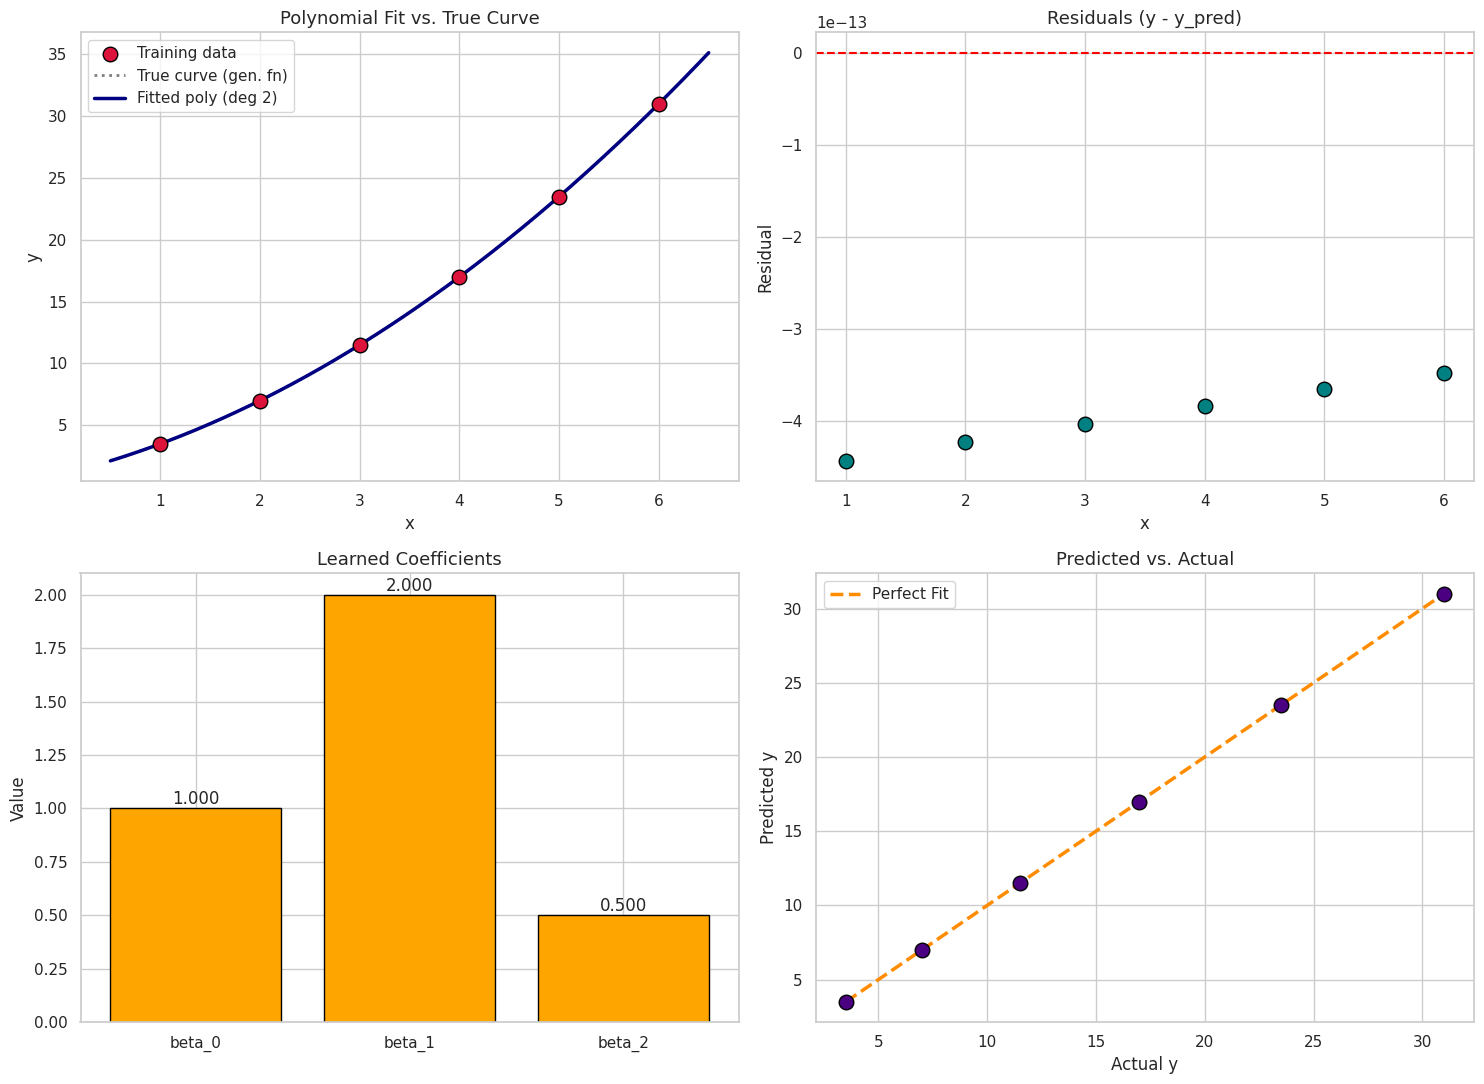

In [17]:
# Fine grid for smooth curves
x_grid = np.linspace(x.min() - 0.5, x.max() + 0.5, 300)
y_grid_pred = model.predict(x_grid)
y_grid_true = 1 + 2*x_grid + 0.5*x_grid**2   # the generating function

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Panel A: fit
axes[0, 0].scatter(x, y, color='crimson', s=110, zorder=5, edgecolor='black', label='Training data')
axes[0, 0].plot(x_grid, y_grid_true, color='gray', lw=2, ls=':', label='True curve (gen. fn)')
axes[0, 0].plot(x_grid, y_grid_pred, color='navy', lw=2.5, label=f'Fitted poly (deg {DEGREE})')
for xi, yi in zip(x, y):
    axes[0, 0].vlines(xi, yi, model.predict(np.array([xi]))[0], color='green', ls='--', alpha=0.5)
axes[0, 0].set_title('Polynomial Fit vs. True Curve', fontsize=13)
axes[0, 0].set_xlabel('x'); axes[0, 0].set_ylabel('y')
axes[0, 0].legend()

# Panel B: residuals
axes[0, 1].axhline(0, color='red', ls='--', lw=1.5)
axes[0, 1].scatter(x, residuals, color='teal', s=110, edgecolor='black', zorder=5)
axes[0, 1].set_title('Residuals (y - y_pred)', fontsize=13)
axes[0, 1].set_xlabel('x'); axes[0, 1].set_ylabel('Residual')

# Panel C: coefficients
labels = ['beta_0'] + [f'beta_{j}' for j in range(1, DEGREE + 1)]
axes[1, 0].bar(labels, model.beta, color='orange', edgecolor='black')
axes[1, 0].set_title('Learned Coefficients', fontsize=13)
axes[1, 0].set_ylabel('Value')
for i, v in enumerate(model.beta):
    axes[1, 0].text(i, v, f'{v:.3f}', ha='center', va='bottom')

# Panel D: predicted vs actual
axes[1, 1].scatter(y, y_pred, color='indigo', s=110, edgecolor='black', zorder=5)
axes[1, 1].plot([y.min(), y.max()], [y.min(), y.max()], color='darkorange', ls='--', lw=2.5, label='Perfect Fit')
axes[1, 1].set_title('Predicted vs. Actual', fontsize=13)
axes[1, 1].set_xlabel('Actual y'); axes[1, 1].set_ylabel('Predicted y')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 9. Predict on New Points

Use the fitted model to estimate `y` for unseen `x` values.


In [18]:
x_new = np.array([2.5, 4.5, 7.0])
y_new = model.predict(x_new)

pred_df = pd.DataFrame({'x_new': x_new, 'y_predicted': np.round(y_new, 4)})
print('=== NEW POINT PREDICTIONS ===')
print(pred_df.to_string(index=False))


=== NEW POINT PREDICTIONS ===
 x_new  y_predicted
   2.5        9.125
   4.5       20.125
   7.0       39.500
